# Prediction of Loan defaults

Using the data of customers in a bank, I will predict if they are likely to default their loan or not. Because the use case is defined by a yes/no question, I will use classification methods and compare them to obtain the best possible outcome.

### Step 1: Import necessary libraries

In [1]:
!pip install skimpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.1 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you 

In [39]:
### Import necessary libraries
import warnings
import xgboost
import numpy as np
import seaborn as sns
import pandas as pd
import codecs
import statsmodels.api as sm
import sklearn as skl
import skimpy as skim
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.formula.api import ols
from statsmodels.formula.api import logit
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from pandas.errors import SettingWithCopyWarning
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

### Step 2: Load, clean and analyse the data

In [40]:
df = pd.read_csv("/data/loans.csv")
print(df.head())

   default  installment  log_income  fico_score  rev_balance  inquiries  \
0        0          829        4.93         737        28.85          0   
1        0          228        4.81         707        33.62          0   
2        0          367        4.51         682         3.51          1   
3        0          162        4.93         712        33.67          1   
4        0          103        4.91         667         4.74          0   

   records  
0        0  
1        0  
2        0  
3        0  
4        0  


In [41]:
# Clean missing values and ensure correct data type
df = df.dropna(subset=['default', 'fico_score']).copy()
df['default'] = df['default'].astype(int)
df.describe()

,default,installment,log_income,fico_score,rev_balance,inquiries,records
count,9516.000000,9516.000000,9516.000000,9516.000000,9516.000000,9516.000000,9516.000000
mean,0.159836,320.142077,4.748656,710.841950,16.988948,1.572930,0.062211
std,0.366473,207.066550,0.265017,37.956246,33.721352,2.200329,0.262406
min,0.000000,16.000000,3.280000,612.000000,0.000000,0.000000,0.000000
25%,0.000000,164.000000,4.590000,682.000000,3.270000,0.000000,0.000000
50%,0.000000,269.500000,4.750000,707.000000,8.690000,1.000000,0.000000
75%,0.000000,435.250000,4.900000,737.000000,18.355000,2.000000,0.000000
max,1.000000,940.000000,6.310000,827.000000,1207.360000,33.000000,5.000000


Now, to help with the comparison of credit score distributions accross the outcomes, I will split the dataset into two separate groups: defaulted loans (default = 1) and not defaulted loans (default = 0)
Split the dataset into two separate groups:

In [42]:
default_df = df[df.default == 1]
print(default_df.head())

    default  installment  log_income  fico_score  rev_balance  inquiries  \
6         1          194        4.65         667         3.84          0   
7         1          131        4.78         722        24.22          0   
57        1          678        5.16         682        41.67          0   
65        1           33        4.53         687         4.49          1   
73        1          225        5.33         677        56.41          0   

    records  
6         1  
7         0  
57        0  
65        0  
73        0  


In [43]:
no_default_df = df[df.default == 0]
print(no_default_df.head())

   default  installment  log_income  fico_score  rev_balance  inquiries  \
0        0          829        4.93         737        28.85          0   
1        0          228        4.81         707        33.62          0   
2        0          367        4.51         682         3.51          1   
3        0          162        4.93         712        33.67          1   
4        0          103        4.91         667         4.74          0   

   records  
0        0  
1        0  
2        0  
3        0  
4        0  


Examine the resulting dataframes

In [44]:
no_default_df.describe()

,default,installment,log_income,fico_score,rev_balance,inquiries,records
count,7995.0,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000
mean,0.0,315.542464,4.752088,713.307067,16.181555,1.428143,0.056535
std,0.0,203.361193,0.260654,38.209948,29.542831,1.997417,0.255646
min,0.0,16.000000,3.280000,612.000000,0.000000,0.000000,0.000000
25%,0.0,163.000000,4.600000,682.000000,3.250000,0.000000,0.000000
50%,0.0,268.000000,4.750000,707.000000,8.630000,1.000000,0.000000
75%,0.0,425.500000,4.910000,742.000000,18.000000,2.000000,0.000000
max,0.0,940.000000,6.310000,827.000000,952.010000,31.000000,5.000000


In [45]:
default_df.describe()

,default,installment,log_income,fico_score,rev_balance,inquiries,records
count,1521.0,1521.000000,1521.000000,1521.000000,1521.000000,1521.000000,1521.000000
mean,1.0,344.319527,4.730618,697.884287,21.232939,2.333991,0.092045
std,0.0,224.068429,0.286276,33.764233,50.066968,2.938440,0.293699
min,1.0,16.000000,3.300000,617.000000,0.000000,0.000000,0.000000
25%,1.0,169.000000,4.560000,672.000000,3.400000,0.000000,0.000000
50%,1.0,290.000000,4.730000,692.000000,8.940000,1.000000,0.000000
75%,1.0,492.000000,4.900000,717.000000,20.700000,3.000000,0.000000
max,1.0,927.000000,5.850000,822.000000,1207.360000,33.000000,2.000000


From the results I can see that there are patterns in the data:

The not default data had high FICO scores (average: 713), indicating strong creditworthiness; moderate installment amounts and low revolving balances, suggesting manageable debt levels; few credit inquiries and minimal derogatory records, reflecting responsible financial behavior; and, stable income levels, inferred from log-transformed income values.

The default data, compared to the not default data, had lower FICO scores (average: 698), indicating weaker credit profiles; higher installment amounts (mean: 344 vs 316), suggesting larger or riskier loans; slightly lower income (log_income: 4.73 vs 4.75), which may affect repayment capacity; higher revolving balances and more credit inquiries, pointing to greater financial stress or credit-seeking behavior; and, more derogatory records, though still rare, indicating some history of credit issues.



### Step 3: Split the data and built a first generic model

I will split the data in train and test dataset and analyse how well the data is distributed. Then, I will generate a first model using only fico scores as variable, to see its accuracy before modeling with all the variables.

In [46]:
df_train,df_test = train_test_split(df,test_size = 0.3,random_state=42,stratify=df['default'])

In [47]:
df_train.describe()

,default,installment,log_income,fico_score,rev_balance,inquiries,records
count,6661.000000,6661.000000,6661.000000,6661.000000,6661.000000,6661.000000,6661.000000
mean,0.159886,322.408497,4.750161,710.726918,17.150354,1.585197,0.063354
std,0.366528,207.900592,0.265933,37.831725,35.747063,2.221479,0.262600
min,0.000000,16.000000,3.280000,612.000000,0.000000,0.000000,0.000000
25%,0.000000,165.000000,4.580000,682.000000,3.310000,0.000000,0.000000
50%,0.000000,273.000000,4.750000,707.000000,8.770000,1.000000,0.000000
75%,0.000000,441.000000,4.910000,737.000000,18.380000,2.000000,0.000000
max,1.000000,940.000000,6.160000,822.000000,1207.360000,33.000000,5.000000


The training data, just as the general data, shows that about 16% of loans defaulted. In the training data, we have an average FICO score of 711 and median installment of 269 which are also around the meand values of the general data.

Most borrowers had moderate income levels, low revolving balances, and few credit inquiries or derogatory records. However, the presence of outliers—such as high inquiries and balances—suggests that while the majority were financially stable, some exhibited riskier credit behavior.

In [48]:
est = logit(formula = 'default ~ fico_score',data = df_train).fit()

print(est.summary())

Optimization terminated successfully.
         Current function value: 0.426576
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 6661
Model:                          Logit   Df Residuals:                     6659
Method:                           MLE   Df Model:                            1
Date:                Fri, 11 Sep 2026   Pseudo R-squ.:                 0.02936
Time:                        21:09:52   Log-Likelihood:                -2841.4
converged:                       True   LL-Null:                       -2927.4
Covariance Type:            nonrobust   LLR p-value:                 2.824e-39
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.1187      0.697     10.208      0.000       5.752       8.486
fico_score    -0.0125      0.

### Step 4: Make predictions and see the model performance

In [49]:
preds = est.predict(df_test)
df_test['predicted_probability'] = preds
# print top 5 predicted probabilities
df_test.head()


,default,installment,log_income,fico_score,rev_balance,inquiries,records,predicted_probability
9206,0,80,5.00,702,34.07,4,0,0.164836
5000,0,479,4.43,737,0.05,0,0,0.113196
2845,0,700,4.78,742,24.03,3,0,0.107095
1205,0,262,4.71,697,5.33,2,0,0.173586
3163,0,307,4.81,747,10.11,6,0,0.101285


Next, I will create a new column called "will_default" that evaluates the predicted probabilities and flags each loan as likely to default or not. I will use a threshold of 25%.
  

In [50]:
df_test['will_default'] = None
df_test = df_test.sort_values(by='default').reset_index(drop=True)
df_test['predicted_probability'] = df_test['predicted_probability'].fillna(0)
df_test['will_default'] = np.where(df_test['predicted_probability']>0.25,1,0).astype(int)

print(df_test)

      default  installment  log_income  fico_score  rev_balance  inquiries  \
0           0          330        4.64         732        14.87          0   
1           0          307        4.93         677         0.04          2   
2           0          333        4.95         737        61.37          2   
3           0          360        4.65         757        12.34          0   
4           0           39        3.60         682         0.90          1   
...       ...          ...         ...         ...          ...        ...   
2850        1          659        5.28         757        26.33          1   
2851        1          200        5.21         762       141.17          1   
2852        1          597        4.88         697        38.54          3   
2853        1          235        4.78         722         0.26          0   
2854        1          248        4.50         652         8.38          1   

      records  predicted_probability  will_default  
0         

With this information I will create a confusion matrix so I can observe your model's performance on the test data by examining predicted vs actual default values.

In [51]:
matrix = confusion_matrix(df_test['default'], df_test['will_default'])
print(matrix)

[[2298  101]
 [ 419   37]]


<Axes: >

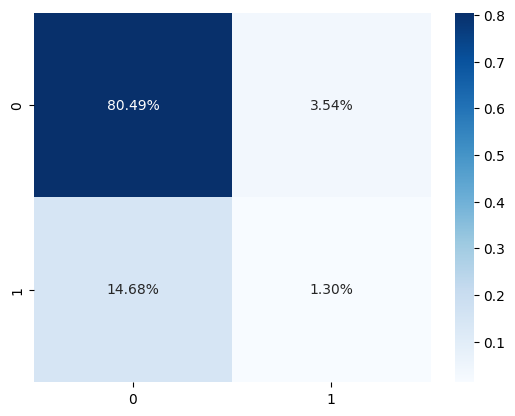

In [52]:
sns.heatmap(matrix/np.sum(matrix), annot=True,
            fmt='.2%', cmap='Blues')

<Axes: >

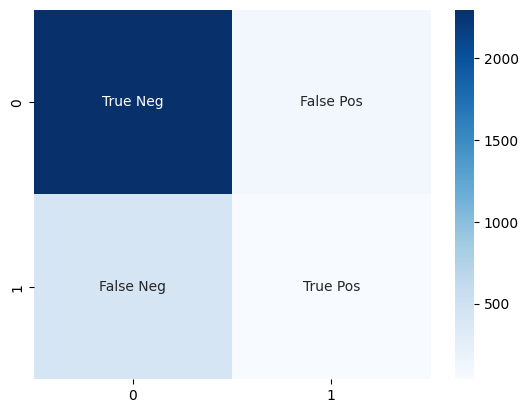

In [53]:
labels = ["True Neg","False Pos","False Neg","True Pos"]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(matrix, annot=labels, fmt="", cmap='Blues')

Now I will print the accuracy of this model and other important metrics

In [54]:
total = len(df_test)
true_pos = matrix[1,1]
false_pos = matrix[0,1]
false_neg = matrix[1,0]
true_neg = matrix[0,0]

acc_rate = (true_pos + true_neg) / total # the probability the model correctly categorizes a data point
error_rate = (false_pos + false_neg) / total # the probability the model incorrectly categorizes a data point

true_pos_rate = true_pos / (true_pos + false_neg) # the probability the model correctly categorizes a data point given it's positive
false_pos_rate = false_pos / (true_neg + false_pos) # the probability the model incorrectly categorizes a negative result as a positive one

true_neg_rate = true_neg / (true_neg + false_pos) # the probability the model correctly categorizes a data point given it's negative
false_neg_rate = false_neg / (true_pos + false_neg) # the probability the model incorrectly categorizes a positive result as a negative one

print(f'Accuracy:{100.0*acc_rate:.3f}%', f'Error:{100.0*error_rate:.3f}%')
print(f'True positive rate:{100.0*true_pos_rate:.3f}%', f'False positive rate:{100.0*false_pos_rate:.3f}%')
print(f'True negative rate:{100.0*true_neg_rate:.3f}%', f'False negative rate:{100.0*false_neg_rate:.3f}%')

Accuracy:81.786% Error:18.214%
True positive rate:8.114% False positive rate:4.210%
True negative rate:95.790% False negative rate:91.886%


The model achieved an accuracy of 81.786%, only using FICO score, indicating that it correctly classified the majority of test cases. While accuracy provides a useful summary metric, when seeing the confusion matrix the model has 14.68% of false negatives. For the use case, this could represent lost customers when applied in reality. To provide more insights, I will build models with all the variables next.

### Step 5: Build Helper Functions to help with model analysis
profit(): Calculates average profit based on predicted probabilities, actual outcomes, and a cutoff threshold. I will use 1000 dollars of profit for all true negatives and 5000 dollars of losses for every false negative.

profit_table(): Generates a table of profits for multiple cutoff values.

best_profit_and_cutoff(): Identifies the cutoff that maximizes profit.

viz_tree(): Generates a tree graphically.

These functions will help to compare different models using a business-centric metric rather than just accuracy.

In [55]:
def profit(y, y_pred, cutoff=0.5, verbose=False):
  '''
  Given a probability cutoff, predicted probabilities, and actual y values,
  calculates the profit per applicant
  '''
  will_default = np.where(y_pred >= cutoff, 1, 0)
  cm = confusion_matrix(y, will_default)
  if verbose:
    ConfusionMatrixDisplay.from_predictions(
        y,
        will_default,
        display_labels = ['No Default', 'Default']
        )
  cm_profit = 1000*cm[0,0]-5000*cm[1,0]
  return cm_profit/len(y)

def profit_table(y, y_pred, cutoffs=np.arange(0,1.01,0.1)):
  '''
  Given predicted probabilities, actual y values, and a set of cutoffs,
  calculates the profit per applicant for each cutoff
  and returns it in a two-column dataframe
  '''
  return pd.DataFrame({'cutoff': cutoffs,
                       'profit': [profit(y, y_pred, cutoff) for cutoff in cutoffs]})

def best_profit_and_cutoff(y, y_pred):
  '''
  Given predicted probabilities and actual y values, returns the optimal
  cutoff and optimal profit per applicant
  '''
  pf = profit_table(y, y_pred)
  idx = pf.profit.idxmax()
  return pf.loc[idx]

def viz_tree(tree, font=12, figsize=(16,10)):
  '''
  draws a classification tree
  '''
  plt.figure(figsize=figsize)  # set plot size (denoted in inches)
  _ = plot_tree(tree,
                feature_names=X.columns,
                filled=True,
                fontsize=font)

### Step 6: Split the original data in train and test datasets


In [56]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)
X = df_train.copy()
y = X.pop('default')
X_test = df_test.copy()
y_test = X_test.pop('default')

### Step 7: Create the logistic regression with all the variables
I will create the logistic regression and find the best profit possible using the helper functions of the previous steps.

In [57]:
formula="default ~ installment + log_income + fico_score + rev_balance + inquiries + records"
est = logit(formula=formula, data=df_train).fit()
print(est.summary())

Optimization terminated successfully.
         Current function value: 0.415078
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 6661
Model:                          Logit   Df Residuals:                     6654
Method:                           MLE   Df Model:                            6
Date:                Fri, 11 Sep 2026   Pseudo R-squ.:                 0.05338
Time:                        21:09:52   Log-Likelihood:                -2764.8
converged:                       True   LL-Null:                       -2920.7
Covariance Type:            nonrobust   LLR p-value:                 2.415e-64
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       9.7634      0.994      9.824      0.000       7.816      11.711
installment     0.0013    

In [58]:
y_pred = est.predict(X_test)
pf_table = profit_table(y_test, y_pred)
bestpf = best_profit_and_cutoff(y_test, y_pred)
print(pf_table)
print(f'Cutoff for best profit:{bestpf['cutoff']}')
print(f'Best profit:{bestpf['profit']}')

    cutoff  profit
0      0.0       0
1      0.1  434000
2      0.2  438000
3      0.3  325000
4      0.4  165000
5      0.5  122000
6      0.6   93000
7      0.7   94000
8      0.8   94000
9      0.9   95000
10     1.0   95000
Cutoff for best profit:0.2
Best profit:438000.0


### Step 8: Build a regression tree with default parameters
I will build a regression tree with default parameters and compare the results with the logistic regression model.

In [59]:
tree = DecisionTreeClassifier(random_state=42)

In [60]:
tree.fit(X,y)

DecisionTreeClassifier(random_state=42)

In [61]:
y_pred = tree.predict_proba(X_test)[:,1]
profit_table(y_test, y_pred)

,cutoff,profit
0,0.0,0
1,0.1,212000
2,0.2,212000
3,0.3,212000
4,0.4,212000
5,0.5,212000
6,0.6,212000
7,0.7,212000
8,0.8,212000
9,0.9,212000


Compared to the logistic regression model, the classification tree has almost half the average profit. This could be because of overfitting. To check that, let's see the depth and number of nodes of the tree.

In [62]:
tree.tree_.max_depth, tree.tree_.node_count

(35, 2515)

With 35 levels and 2515 nodes overfitting is corroborated, to address it, I will use cost-complexity pruning.

### Step 9: Build the best pruned tree
To prune a tree, the parameter to use is the cpp_alpha, which penalizes the tree complexity. Then, the process to obtain the best pruned tree possible will be the following:
- Generate a sequence of pruneed trees for different ccp_alpha values
- Evaluate the performance of each tree on out-of-sample data.
- Select the tree that offers the best trade-off between complexity and predictive performance

In that way, I will ensure that the final tree is smaller, interpretable, and generalizes better.

In [63]:
tree = DecisionTreeClassifier(random_state=42)

In [64]:
path = tree.cost_complexity_pruning_path(X,y)

In [65]:
alphas = path.ccp_alphas
print(f"The process will generate {len(alphas)} trees.")

The process will generate 436 trees.


In [66]:
trees = []
for alpha in alphas:
  tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
  tree.fit(X,y)
  trees.append(tree)

Now I will find the tree with the highest test profit.

In [67]:
def all_trees_profits_cutoffs(X,y):
  max_profit = []
  best_cutoff = []
  for tree in trees:
    y_pred = tree.predict_proba(X)[:,1]
    pf = best_profit_and_cutoff(y, y_pred)
    max_profit.append(pf['profit'])
    best_cutoff.append(pf['cutoff'])
  return max_profit, best_cutoff

In [68]:
train_profits, train_cutoffs = all_trees_profits_cutoffs(X,y)
test_profits, test_cutoffs = all_trees_profits_cutoffs(X_test,y_test)

Plotting the results to see the performance more clearly.

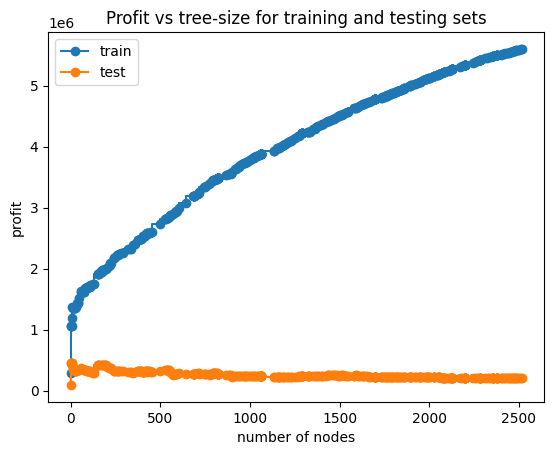

In [69]:
node_counts = [tree.tree_.node_count for tree in trees]
depth = [tree.tree_.max_depth for tree in trees]

fig, ax = plt.subplots()
ax.set_xlabel("number of nodes")
ax.set_ylabel("profit")
ax.set_title("Profit vs tree-size for training and testing sets")
ax.plot(node_counts, train_profits, marker="o", label="train", drawstyle="steps-post")
ax.plot(node_counts, test_profits, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

Zooming in on the first section of the chart.

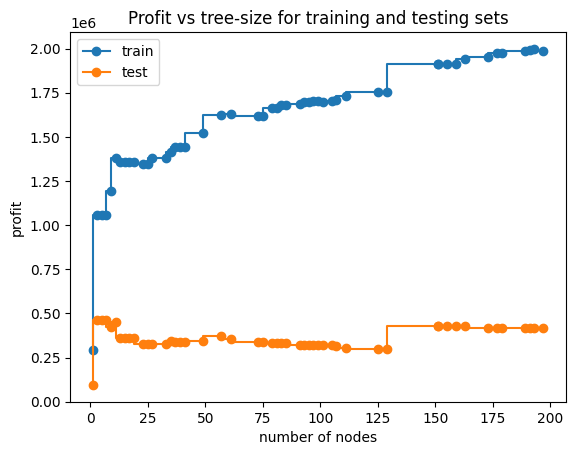

In [70]:
fig, ax = plt.subplots()
ax.set_xlabel("number of nodes")
ax.set_ylabel("profit")
ax.set_title("Profit vs tree-size for training and testing sets")
ax.plot(node_counts[-50:], train_profits[-50:], marker="o", label="train", drawstyle="steps-post")
ax.plot(node_counts[-50:], test_profits[-50:], marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [71]:
opt_idx = np.argmax(test_profits)

print(f"Profit of max-profit tree = ${max(test_profits):.2f}")
print(f"Size of max-profit tree = {node_counts[opt_idx]} nodes")
print(f"Optimal cutoff for chosen tree = {test_cutoffs[opt_idx]:.2f}")

Profit of max-profit tree = $462000.00
Size of max-profit tree = 7 nodes
Optimal cutoff for chosen tree = 0.20


Now the tree's profit is higher than the profit from the logistic regression model. The tree is also much smaller than the first one built, improving interpretability. I will use the viz_tree function to check the tree.

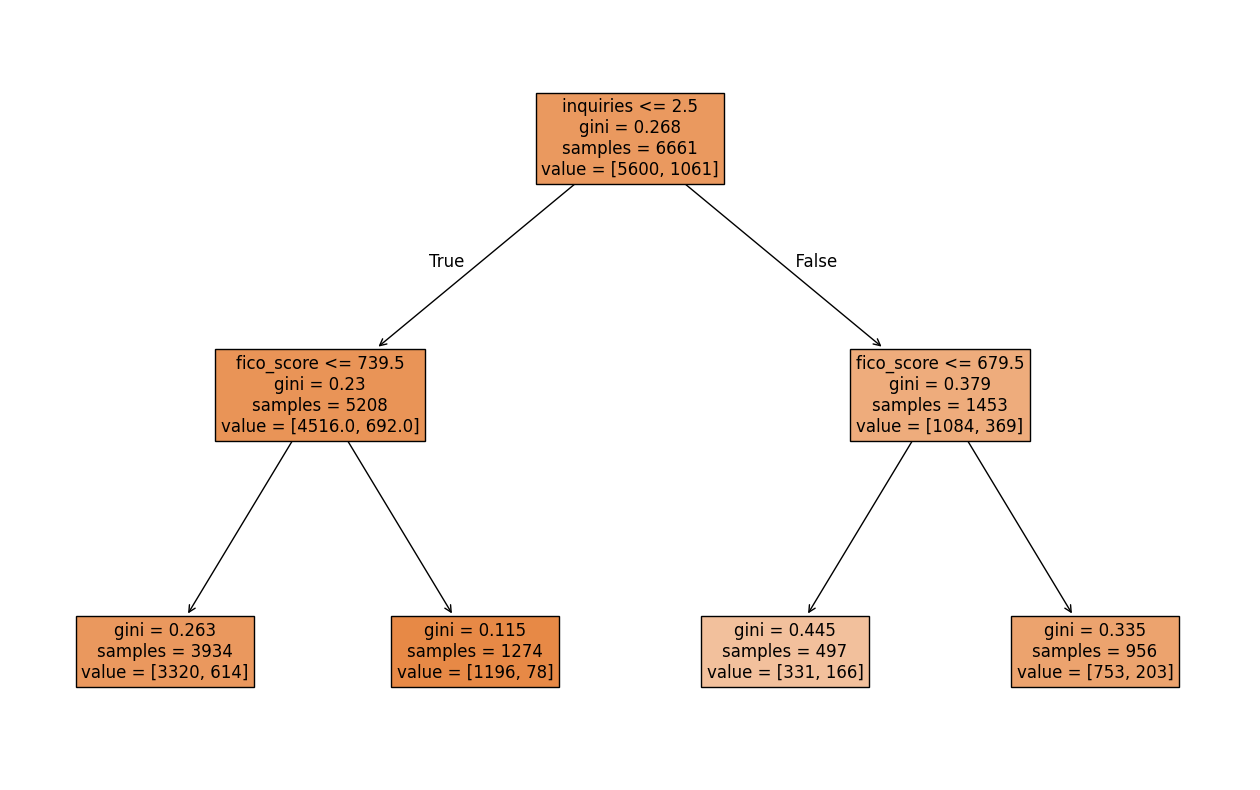

In [72]:
tree = trees[opt_idx]
viz_tree(tree)



---



---



---



---



### Step 10: Build an XGBoost model to test its accuracy
The last tree got good results, however, there is a way to obtain good results with more stability, meaning that when outliers came, the model will still be good enough to try and make a prediction.

In [77]:
X = df.drop(['default'], axis=1)
y = df['default']

# Encode string class values as integers to avoid errors in newer versions of XGBoost
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(y)
y = label_encoder.transform(y)

# Splitting data into training and test set:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
eval_set=[(X_test, y_test)]
print(X_train.shape, X_test.shape)

(6661, 6) (2855, 6)


In [78]:
print('Initializing xgboost.sklearn.XGBClassifier and starting training...')

st = datetime.now()

clf = xgboost.sklearn.XGBClassifier(
    objective="binary:logistic",
    learning_rate=0.05,
    seed=9616,
    max_depth=20,
    gamma=10,
    n_estimators=500,
    early_stopping_rounds=20,
    eval_metric="auc",
    )

clf.fit(X_train, y_train,
        eval_set=eval_set,
        verbose=False)
print(datetime.now()-st)

Initializing xgboost.sklearn.XGBClassifier and starting training...
0:00:00.494445


### Step 11: Test the model

In [84]:
### predict give the number of correct classifications when cutoff is 0.5
### Using this information, I can find the accuracy of the model
accuracy = accuracy_score(y_test,clf.predict(X_test))
print("Accuracy: %.10f%%" % (accuracy * 100.0))

### predict_proba give the probabilities for the prediction to be 0 or 1
### Using this information, I can find the best cutoff and the best profit possible
accuracy_per_roc_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
print("ROC-AUC: %.10f%%" % (accuracy_per_roc_auc * 100))

pf_table = profit_table(y_test, clf.predict_proba(X_test)[:,1])
bestpf = best_profit_and_cutoff(y_test, clf.predict_proba(X_test)[:,1])
print(pf_table)
print(f'Cutoff for best profit:{bestpf['cutoff']}')
print(f'Best profit:{bestpf['profit']}')

Accuracy: 83.8879159370%
ROC-AUC: 64.2947717164%
    cutoff  profit
0      0.0       0
1      0.1  328000
2      0.2  415000
3      0.3  172000
4      0.4   95000
5      0.5   95000
6      0.6   95000
7      0.7   95000
8      0.8   95000
9      0.9   95000
10     1.0   95000
Cutoff for best profit:0.2
Best profit:415000.0


I can see that the best average profit (415000) occurs with a cutoff of 0.2. To know which variables have been of most importance for the XGBoost model, I will use the xgboost.plot_importance function.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

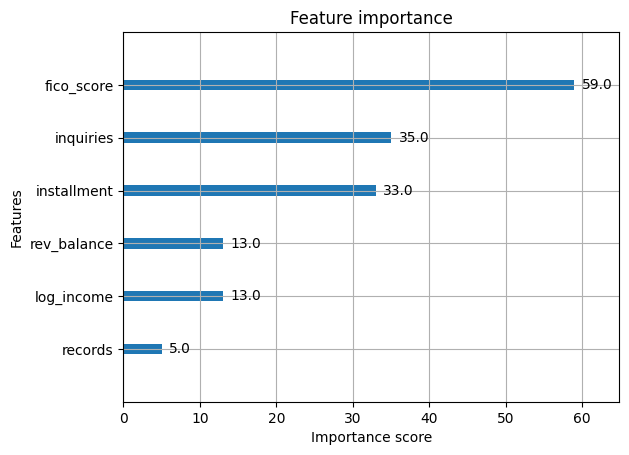

In [76]:
xgboost.plot_importance(clf)

## Conclusion
After all the models tested, the best profit was obtained by the XGBoost model, however, this model is not easily interpreted. If the business needs interpretability as one of their key features, I would choose the classification tree model. A simple logistic model could be chosen when interpretability and stability are key, because the tree is not as stable and the XGBoost model is not as interpretable as the logistic model.